## AIA Assignment 1

Contributors: Ashutosh Joshi, Pratik Waghmode, Darshil Savlia

# LeNet-1 (1989) Implementation

This notebook is reimplementation of the original Convnet paper from LeCun et.al used for digit recognition in handwritten zip codes [^1]. The neural net was then evolved from this first version over a decade [^2].

## References
[^1]: LeCun, Y. et al. (1989). Backpropagation applied to Handwritten Zip Code Recognition. [Link to PDF](http://yann.lecun.com/exdb/publis/pdf/lecun-89e.pdf)

[^2]: LeCun, Y. et al. (1998) GradientBased Learning Applied to Document Recognition



In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


torch.manual_seed(42)

## Table of Contents
1. [Data Preparation](#data-preparation)
2. [Model Architecture](#model-architecture)
3. [Forward Pass](#forward-pass)
4. [Training Loop](#training-loop)
5. [Results](#results)

## Data Preparation

The data pre-processing is done in the notebook **pytorch_playground**, which load, resizes to 16x16 image from 28x28 image in MNIST Dataset, and stores the subset of the dataset to npz file in data directory.
* The saved dataset contains 7291 training and 2007 test images of handwritten digits and corresponding labels (0-9)

In [ ]:
data_train = data = np.load("datasets/train1989.npz")
data_test = np.load("datasets/test1989.npz")

# Access arrays inside
Xtr = torch.from_numpy(data_train["X"])
Ytr = torch.from_numpy(data_train["Y"])

Xte = torch.from_numpy(data_test["X"])
Yte = torch.from_numpy(data_test["Y"])

**Task** Check the shape of the training and test data and labels.

In [ ]:
##TODO: Write code for checking shape.
print("Xtr shape:", Xtr.shape)
print("Ytr shape:", Ytr.shape)
print("Xte shape:", Xte.shape)
print("Yte shape:", Yte.shape)

Xtr shape: torch.Size([7291, 1, 16, 16])
Ytr shape: torch.Size([7291, 10])
Xte shape: torch.Size([2007, 1, 16, 16])
Yte shape: torch.Size([2007, 10])


## Model Architecture

Score function is the mathematical mapping that takes the input (e.g. image of handwritten digit) and transforms into scores for each possible class.  In other words, forward pass of a neural network is the score function. The simplest being $$f(x, W, b) = f_a(\sum_{i=1}^{n} w_i x_i + b)$$
* $W$: (weights) are the parameters of the neural network
* $x$: features chosen for the problem (in this case, grayscale value of pixels)
* $f_a$: chosen activation function for introducing non-linearity (e.g. tanh or relu)

### Score function: Weights and bias
The notebook uses paper implementation of the weight initialization which requires fan_in(number of input connections to a neuron) which prevents vanishing gradients.

In [ ]:
def init_weights(fan_in, *shape):
    """Weight initialization as described in the paper"""
    weight = (torch.rand(*shape) - 0.5) * 2 * 2.4 / fan_in
    return nn.Parameter(weight)

**Task** you'll need to implement TODO section, with following specification for parameters
* H1 layer is a 2d Convolution layer with 12 filter with mask 5x5 and stride of 2
* H3 layer is fully connected layer (FC) where input shape is (1, 192) output shape is (1, 30)
* Final layer is also FC mapping to 10 digit classes
* activation function is tanh
* mac, act are the number of multiply-accumulate and activations, respectively.

In [ ]:
macs = 0
acts = 0

# H1 layer parameters
H1w = init_weights(1*5*5, 12, 1, 5, 5)
H1b = nn.Parameter(torch.zeros(12, 8, 8))
assert H1w.numel() + H1b.numel() == 1068
macs += (5*5*1) * (8*8) * 12 + (8*8*12)
acts += (8*8) * 12
assert macs == 19968

# H2 layer parameters
H2w = init_weights(5*5*8, 12, 8, 5, 5)
H2b = nn.Parameter(torch.zeros(12, 4, 4))
assert H2w.numel() + H2b.numel() == 2592
macs += (5*5*8) * (4*4) * 12 + 192
acts += (4*4) * 12
assert macs == 58560

# H3 fully connected layer
H3w = init_weights(192, 30, 192)
H3b = nn.Parameter(torch.zeros(30))
assert H3w.numel() + H3b.numel() == 5790
macs += 192 * 30 + 30
acts += 30
assert macs == 64350

# Output layer
outw = init_weights(30, 10, 30)
outb = nn.Parameter(-torch.ones(10))
assert outw.numel() + outb.numel() == 310
macs += 30 * 10 + 10
acts += 10
assert macs == 64660

**Task** Find out the following features of the model architecture
   * Parameters:
   
   H1: 300 + 768 = 1068, H2  : 2400 + 192 = 2592, H3: 5760 + 30 = 5790, Out: 300 + 10 = 310

   Total: 9760

   * macs: 19968 + 38592 + 5790 + 310 = 64660

   * activations:1000

Enter answer here

### Score function: Forward pass

The weights, bias, activation function in each layer of neural network define the forward pass. The forward pass is the inference and a major step in training.

**Task** you'll need to implement TODO section in forward pass in following cell, with following specification as in the paper
* H1 layer is a 2d Convolution layer with 12 filter with mask 5x5 and stride of 2. Padding is given.
* H3 layer is fully connected layer (FC) where input shape is (1, 192) output shape is (1, 30)
* Final layer is also FC mapping to 10 digit classes
* activation function is tanh

In [ ]:
def forward(x):
    x = F.pad(x, (2, 2, 2, 2), mode='constant', value=-1.0)

    # H1 layer
    x = F.conv2d(x, H1w, stride=2) + H1b
    x = torch.tanh(x)

    # H2 layer
    x = F.pad(x, (2, 2, 2, 2), mode='constant', value=-1.0)
    slice1 = F.conv2d(x[:, 0:8],  H2w[0:4],  stride=2)
    slice2 = F.conv2d(x[:, 4:12], H2w[4:8],  stride=2)
    slice3 = F.conv2d(torch.cat([x[:, 0:4], x[:, 8:12]], dim=1), H2w[8:12], stride=2)
    x = torch.cat((slice1, slice2, slice3), dim=1) + H2b
    x = torch.tanh(x)

    x = x.flatten(start_dim=1)   # (1, 192)

    # H3 fully connected
    x = x @ H3w.T + H3b          # (1, 30)
    x = torch.tanh(x)

    # Output layer
    x = x @ outw.T + outb         # (1, 10)
    x = torch.tanh(x)

    assert x.shape[1] == 10
    return x

### Loss Function: Error

Loss function measures how good the model is in predicting. High loss means the score for wrong digit is high and right digit is low. It is used in ML training for optimizing the network parameters. Error is a more intuitive metric for judgment of overall training performance.

**Task** Update the loss function in following cell

In [ ]:
def train_step(optimizer, x, y):
    """Single training step"""
    # Zero gradients
    optimizer.zero_grad()

    # TODO: Forward pass and compute loss
    yhat = forward(x)
    loss = torch.mean((y - yhat)**2)
    #loss =

    # Backward pass
    loss.backward()

    # Update parameters
    optimizer.step()

    return loss.item()

Following functions visualize and report the convergence of ML training

In [ ]:
def eval_split(split, X_tr, Y_tr, X_te, Y_te):
    X, Y = (X_tr, Y_tr) if split == 'train' else (X_te, Y_te)
    yhat = forward(X)

    loss = torch.mean((Y - yhat)**2)
    err = torch.mean((Y.argmax(dim=1) != yhat.argmax(dim=1)).float())
    misses = int(err.item() * Y.shape[0])

    print(f"eval: split {split:5s}. loss {loss.item():e}. error {err.item()*100:.2f}%. misses: {misses}")
    return loss.item(), err.item(), misses

def plot_metrics(train_errs, test_errs):
    plt.figure(figsize=(10, 5))
    plt.plot(train_errs, label='Train Error', color='blue', marker='o')
    plt.plot(test_errs, label='Test Error', color='orange', marker='s')
    plt.title('Training vs Test Error')
    plt.xlabel('Epoch')
    plt.ylabel('Error (%)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

### Optimization: Model training


Epoch 1/30
eval: split train. loss 3.595185e-01. error 88.79%. misses: 6474
eval: split test . loss 3.596077e-01. error 88.34%. misses: 1772

Epoch 2/30
eval: split train. loss 2.780548e-01. error 44.04%. misses: 3211
eval: split test . loss 2.919954e-01. error 47.04%. misses: 943

Epoch 3/30
eval: split train. loss 1.001542e-01. error 14.18%. misses: 1034
eval: split test . loss 1.176398e-01. error 17.19%. misses: 344

Epoch 4/30
eval: split train. loss 6.103108e-02. error 8.24%. misses: 600
eval: split test . loss 8.117284e-02. error 11.36%. misses: 228

Epoch 5/30
eval: split train. loss 4.663664e-02. error 6.20%. misses: 452
eval: split test . loss 6.667320e-02. error 9.77%. misses: 195

Epoch 6/30
eval: split train. loss 3.931530e-02. error 5.31%. misses: 387
eval: split test . loss 6.141889e-02. error 9.02%. misses: 180

Epoch 7/30
eval: split train. loss 3.162161e-02. error 4.39%. misses: 320
eval: split test . loss 5.305914e-02. error 8.02%. misses: 160

Epoch 8/30
eval: split

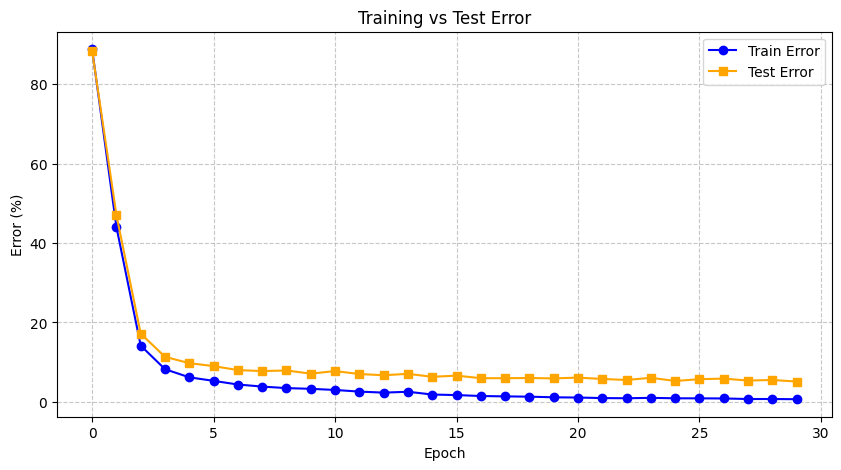

In [ ]:
# Parameters
num_epochs = 30
batch_size = 32
params = [H1w, H1b, H2w, H2b, H3w, H3b, outw, outb]
optimizer = torch.optim.SGD(params, lr=0.5)

history = {'train_err': [], 'test_err': []}
for pass_num in range(num_epochs):
    # Shuffle training data each epoch
    perm = torch.randperm(Xtr.shape[0])
    Xtr_shuffled = Xtr[perm]
    Ytr_shuffled = Ytr[perm]

    for i in range(0, Xtr.shape[0], batch_size):
        x = Xtr_shuffled[i:i+batch_size]
        y = Ytr_shuffled[i:i+batch_size]
        loss = train_step(optimizer, x, y)

    print(f"\nEpoch {pass_num + 1}/{num_epochs}")
    train_loss, train_err, train_misses = eval_split('train', Xtr, Ytr, Xte, Yte)
    test_loss, test_err, test_misses = eval_split('test', Xtr, Ytr, Xte, Yte)
    history['train_err'].append(train_err * 100)
    history['test_err'].append(test_err * 100)

plot_metrics(history['train_err'], history['test_err'])

**Task** In 1989 the training of the CNN took few days.

* What is the training time of your implementation (number of epochs=23)
* Which layer of neural network needs most mac operations (arithmetic)
* How many bytes are transferred to/from memory by each layer considering the input output, and weights

2 trails with different batch sizes, and learning rates were done

trial 1: batch size 1, lr = 0.03, epochs = 23

trial 2: batch size = 32, lr = 0.5, epochs = 30

##training time:

trial 1: 8 minutes

trial 2: 1 minute

##most mac operations: H2 (38592)

## byte transfer :

(H1 + H2 + H3 + Out = Total)

trial 1:
8944 + 18048 + 24048 + 1400 = 52440

trial 2:
153766 + 256128 + 51576 + 6360 = 467840

As seen, the ratio between bytes for H1 and H2 for the 2 trials is around 16, while that of the H3 and output layers is much smaller. The bytes per sample can be computed by dividing by the batch size(32) for trial 2.

The efficiency observed in trial 2 is because the weights/biases are loaded once per batch regardless of batch size, hence the layers which are more weight dominant have lower cost, as seen for H3 and Output.

# Notes: Ideas on experiments
* Even though the 1989 LeCun paper used MSE, the modern standard for digit recognition is Cross-Entropy.
* different learning rates
* different optimizer: Adam
* Visualize the feature maps
* weight decay, regularization
* LeNet-1 Network Class in JAX
    * image batch: (7291, 20, 20, 1)→ interpreted as NHWC (batch, height, width, channels) in JAX. (7291, 1, 20, 20) in Pytorch.
    * weights: (12, 1, 5, 5)→ interpreted as (out_channels, in_channels, filter_height, filter_width)
    * In pytorch, NCHW is standard dimension format. you must tell JAX which dimension format you’re using. Correct usage: NHWC input, OIHW kernel. Output dimension same as bias